In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
# Dataset tips — restauracja, 244 rachunki
tips = sns.load_dataset('tips')
# Dane sprzedaży TechShop (z W08)
miesiace = ['Sty', 'Lut', 'Mar', 'Kwi', 'Maj', 'Cze']
sprzedaz_2024 = [45230, 38920, 52100, 48700, 55200, 62300]
sprzedaz_2023 = [41000, 35000, 48000, 44000, 50000, 58000]
kategorie = ['Komputery', 'Akcesoria', 'Audio', 'Storage']
sprzedaz_kat = [15899.94, 2939.83, 1199.97, 349.93]
print(f"Tips dataset: {tips.shape}")
print(tips.head(3))

Tips dataset: (244, 7)
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3


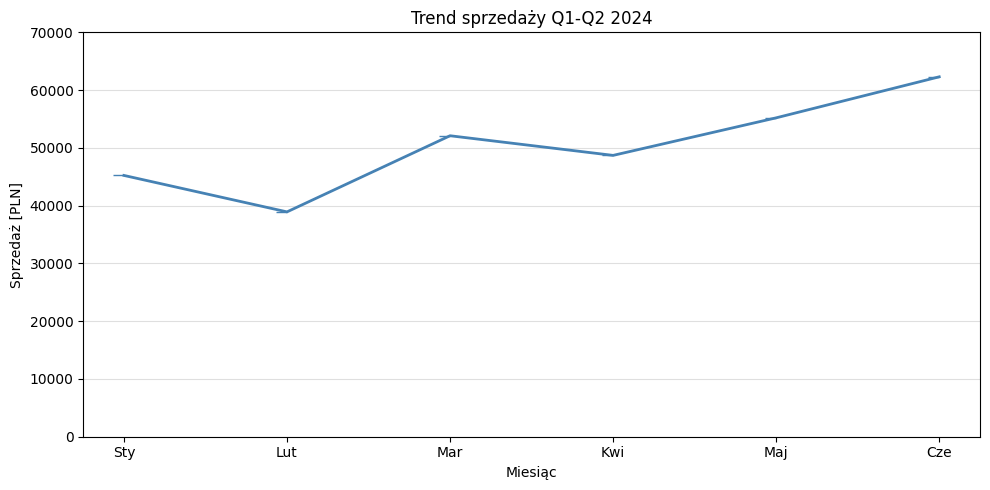

Zapisano: trend_2024.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(miesiace, sprzedaz_2024,
 color='steelblue', # 'steelblue'
 linewidth=2, # 2
 marker=0, # 'o'
 markersize=8)
ax.set_title('Trend sprzedaży Q1-Q2 2024') # 'Trend sprzedaży Q1-Q2 2024'
ax.set_xlabel('Miesiąc') # 'Miesiąc'
ax.set_ylabel('Sprzedaż [PLN]') # 'Sprzedaż [PLN]'
ax.set_ylim(0, 70000)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('trend_2024.png', dpi=100)
plt.show()
plt.close()
print("Zapisano: trend_2024.png")

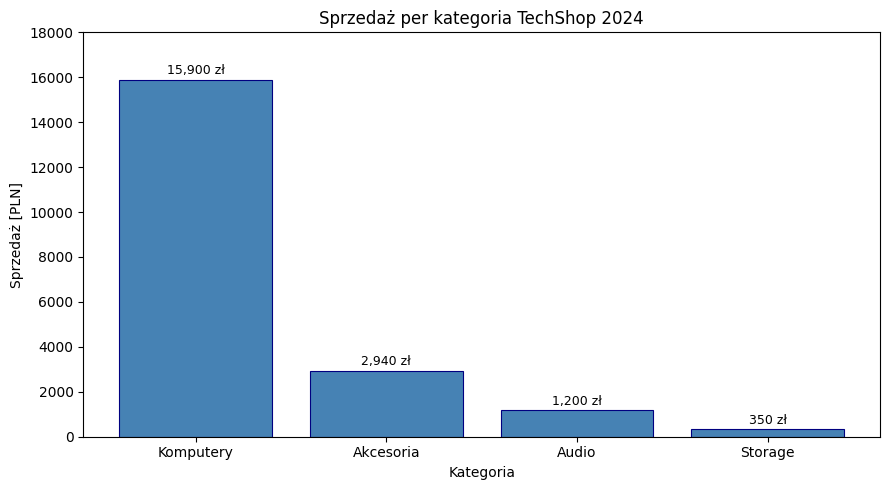

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
slupki = ax.bar(kategorie, 
                sprzedaz_kat, 
                color='steelblue',
                edgecolor='navy',
                linewidth=0.8)

# Dodanie wartości nad słupkami
for slupek, wartosc in zip(slupki, sprzedaz_kat):
    ax.text(
        slupek.get_x() + slupek.get_width() / 2,
        slupek.get_height() + 100, # Lekko nad słupkiem
        f'{wartosc:,.0f} zł', 
        ha='center', va='bottom', fontsize=9 
    )

ax.set_title('Sprzedaż per kategoria TechShop 2024') 
ax.set_xlabel('Kategoria')
ax.set_ylabel('Sprzedaż [PLN]')
ax.set_ylim(0, 18000)
plt.tight_layout()
plt.savefig('sprzedaz_kategorie.png', dpi=100)
plt.show()
plt.close()

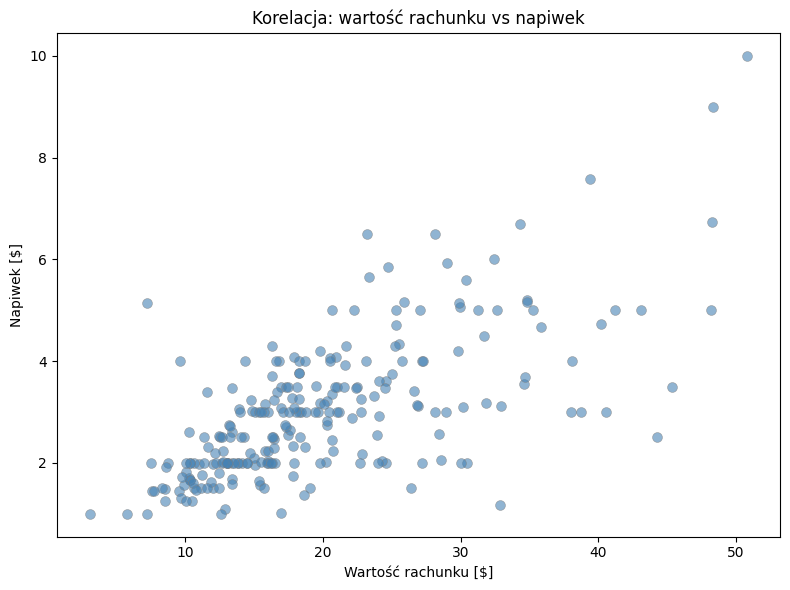

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    tips['total_bill'], 
    tips['tip'], 
    alpha=0.6, 
    color='steelblue',
    s=50, 
    edgecolors='gray',
    linewidth=0.5
)
ax.set_title('Korelacja: wartość rachunku vs napiwek')
ax.set_xlabel('Wartość rachunku [$]')
ax.set_ylabel('Napiwek [$]') 
plt.tight_layout()
plt.savefig('scatter_tips.png', dpi=100)
plt.show()
plt.close()

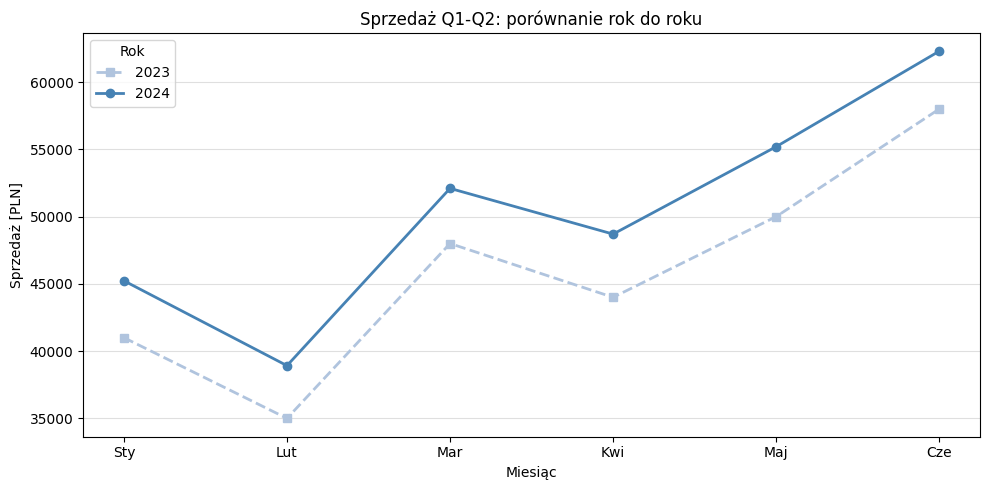

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(miesiace, sprzedaz_2023, label='2023', color='lightsteelblue', linewidth=2, marker='s', linestyle='--') 
ax.plot(miesiace, sprzedaz_2024, label='2024', color='steelblue', linewidth=2, marker='o') 

ax.set_title('Sprzedaż Q1-Q2: porównanie rok do roku')
ax.set_xlabel('Miesiąc')
ax.set_ylabel('Sprzedaż [PLN]')
ax.legend(title='Rok', loc='upper left') 
ax.grid(axis='y', alpha=0.4) 
plt.tight_layout()
plt.savefig('porownanie_lat.png', dpi=100)
plt.show()
plt.close()

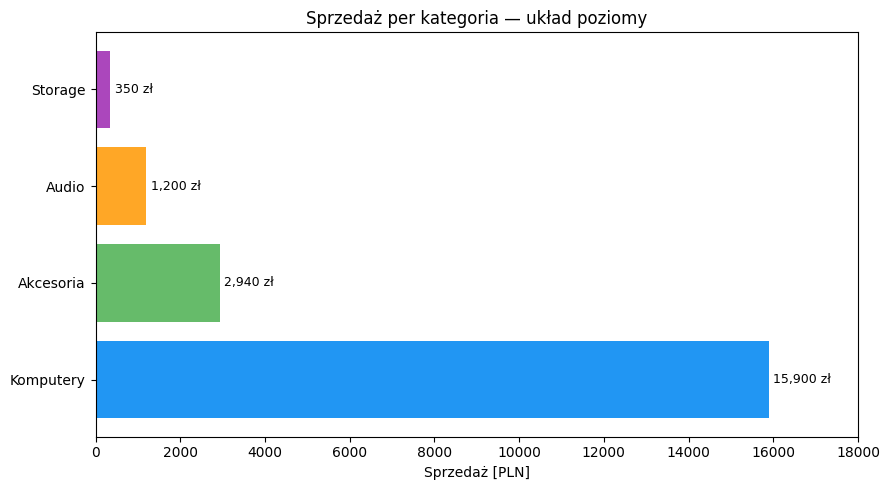

Zapisano: kategorie_poziome.png


In [15]:
kolory_kat = ['#2196F3', '#66BB6A', '#FFA726', '#AB47BC']
fig, ax = plt.subplots(figsize=(9, 5))
# barh = horizontal bar
ax.barh(kategorie, # kategorie
 sprzedaz_kat, # sprzedaz_kat
 color=kolory_kat)
# Etykiety wartości przy słupkach
for i, (kat, wartosc) in enumerate(zip(kategorie, sprzedaz_kat)):
 ax.text(wartosc + 100, i,
 f'{wartosc:,.0f} zł',
 va='center', fontsize=9)
ax.set_title('Sprzedaż per kategoria — układ poziomy')
ax.set_xlabel('Sprzedaż [PLN]')
ax.set_xlim(0, 18000)
plt.tight_layout()
plt.savefig('kategorie_poziome.png', dpi=100)
plt.show()
plt.close()
print("Zapisano: kategorie_poziome.png")

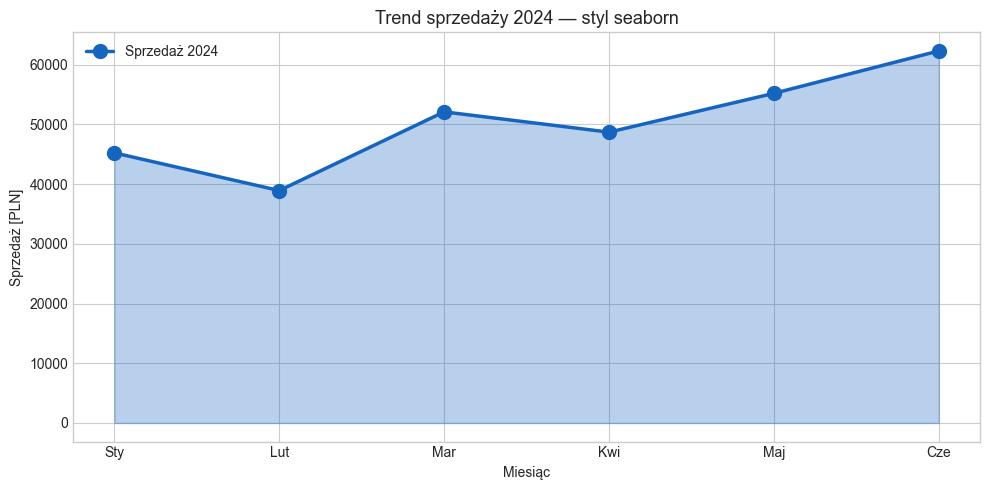

Zapisano: trend_styl.png


In [18]:
# Zastosuj styl
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(miesiace, sprzedaz_2024,
 color='#1565C0',
 linewidth=2.5,
 marker='o',
 markersize=10,
 label='Sprzedaż 2024')
ax.fill_between(miesiace, sprzedaz_2024,
 alpha=0.3, # przezroczystość 0-1; subtelny efekt = 0.1-0.2
 color='#1565C0') # ten sam kolor co linia powyżej dla spójności
ax.set_title('Trend sprzedaży 2024 — styl seaborn', fontsize=13)
ax.set_xlabel('Miesiąc')
ax.set_ylabel('Sprzedaż [PLN]')
ax.legend()
plt.tight_layout()
plt.savefig('trend_styl.png', dpi=100)
plt.show()
plt.close()
# Przywróć domyślny styl
plt.style.use('default')
print("Zapisano: trend_styl.png")


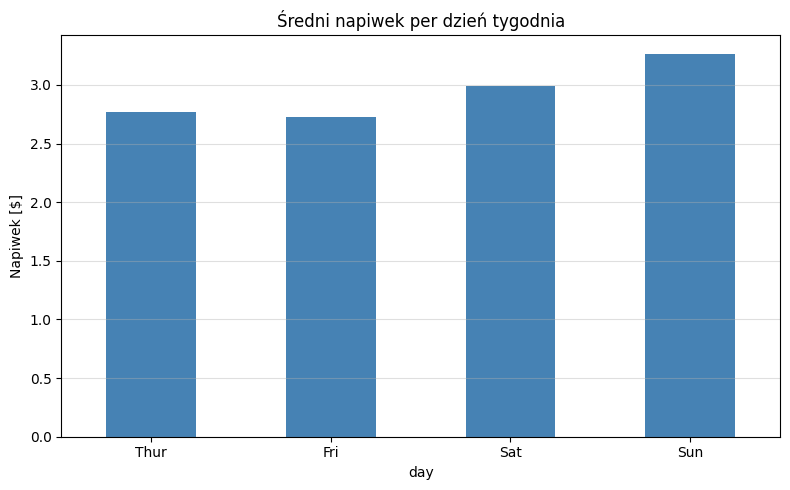

In [19]:
sredni_napiwek = tips.groupby('day', observed=True)['tip'].mean().round(2) 

ax = sredni_napiwek.plot(
    kind='bar', 
    figsize=(8, 5),
    color='steelblue',
    title='Średni napiwek per dzień tygodnia', 
    ylabel='Napiwek [$]',
    rot=0
)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('napiwek_dzien.png') 
plt.show()
plt.close()

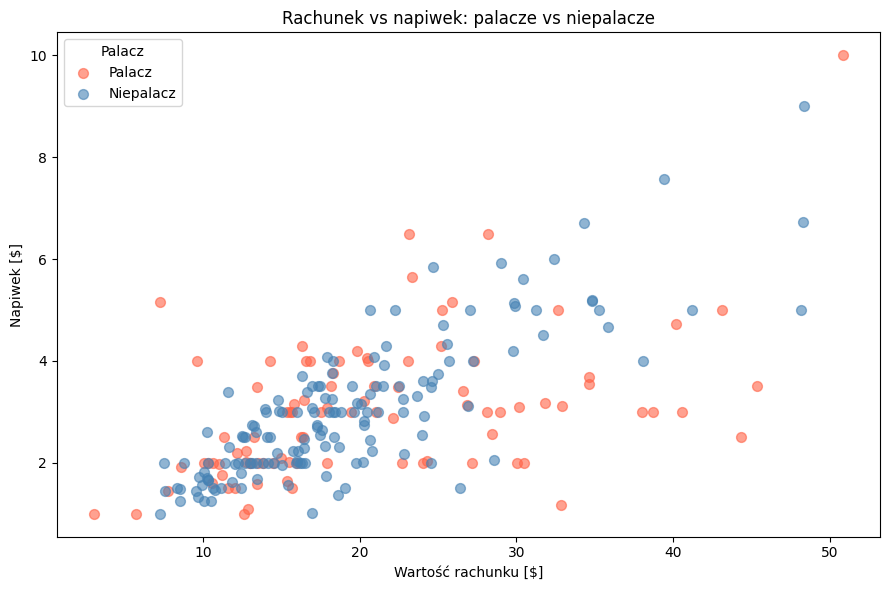

Zapisano: scatter_palacze.png


In [20]:
fig, ax = plt.subplots(figsize=(9, 6))
# Podziel na dwie grupy i narysuj osobno
palacze = tips[tips['smoker'] == 'Yes']
niepalacze = tips[tips['smoker'] == 'No']
ax.scatter(palacze['total_bill'], # palacze['total_bill']
 palacze['tip'], # palacze['tip']
 alpha=0.6, color='tomato', label='Palacz', s=50)
ax.scatter(niepalacze['total_bill'], # niepalacze['total_bill']
niepalacze['tip'], # niepalacze['tip']
 alpha=0.6, color='steelblue', label='Niepalacz', s=50)
ax.set_title('Rachunek vs napiwek: palacze vs niepalacze')
ax.set_xlabel('Wartość rachunku [$]')
ax.set_ylabel('Napiwek [$]')
ax.legend(title='Palacz')
plt.tight_layout()
plt.savefig('scatter_palacze.png', dpi=100)
plt.show()
plt.close()
print("Zapisano: scatter_palacze.png")

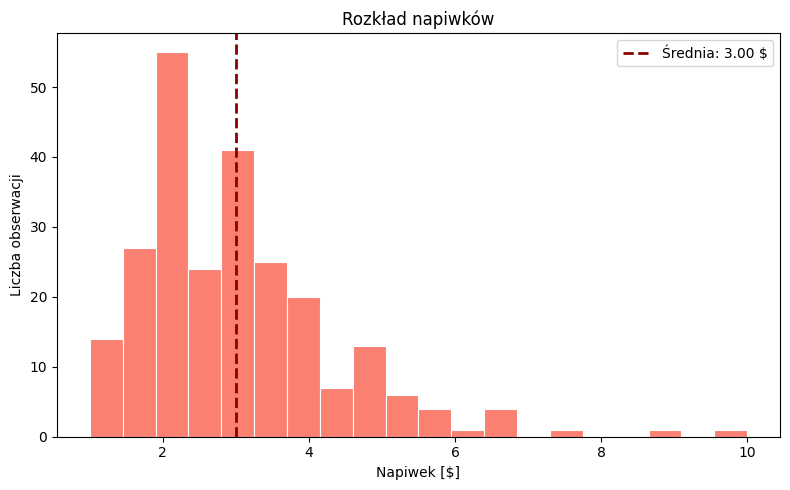

Zapisano: histogram_napiwki.png


In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(tips['tip'], # tips['tip']
 bins=20, # spróbuj 10, 20, 30 — który najczytelniej?
 color='salmon',
 edgecolor='white',
 linewidth=0.8)
ax.set_title('Rozkład napiwków')
ax.set_xlabel('Napiwek [$]')
ax.set_ylabel('Liczba obserwacji')
# Dodaj pionową linię — średnia
ax.axvline(tips['tip'].mean(),
 color='darkred',
 linewidth=2,
 linestyle='--',
 label=f"Średnia: {tips['tip'].mean():.2f} $")
ax.legend()
plt.tight_layout()
plt.savefig('histogram_napiwki.png', dpi=100)
plt.show()
plt.close()
print("Zapisano: histogram_napiwki.png")


sex     Male  Female
time                
Lunch     33      35
Dinner   124      52


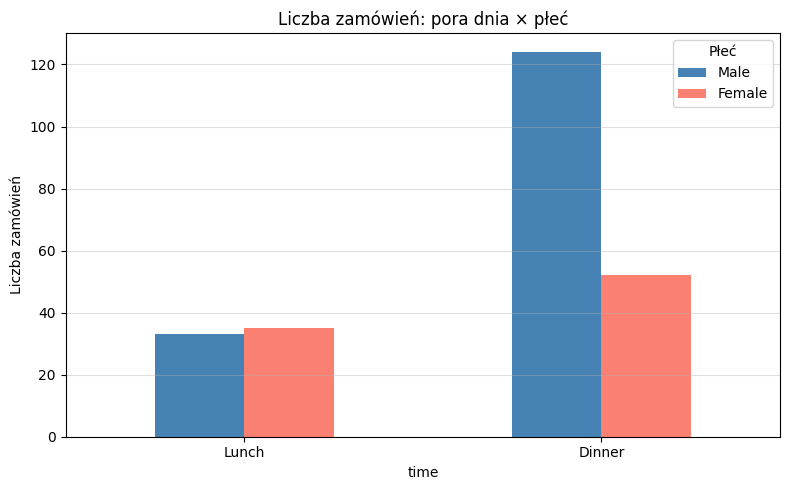

Zapisano: zamowienia_pora.png


In [26]:
# Zlicz zamówienia per pora dnia i płeć
count_df = tips.groupby(['time', 'sex'], observed=True)['total_bill'].count().unstack()
print(count_df)
# Wykres słupkowy grupowany — pora dnia w wierszach, płeć w kolumnach
ax = count_df.plot(
 kind='bar', # 'bar'
 figsize=(8, 5),
 color=['steelblue', 'salmon'],
 title='Liczba zamówień: pora dnia × płeć',
 ylabel='Liczba zamówień',
 rot=0
)
ax.legend(title='Płeć')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('zamowienia_pora.png', dpi=100)
plt.show()
plt.close()
print("Zapisano: zamowienia_pora.png")


Z wykresów wynika, że klienci zostawiają największe napiwki w niedziele. Pora obiadowa (dinner) generuje znacznie więcej zamówień niż lunch, przy czym w trakcie wieczornych wyjść płacącymi są w zdecydowanej większości mężczyźni . Jako menedżer restauracji zadbałbym o wzmocnioną obsadę kelnerską podczas weekendowych obiadów, aby maksymalizować zadowolenie gości z wysokim potencjałem napiwkowym.

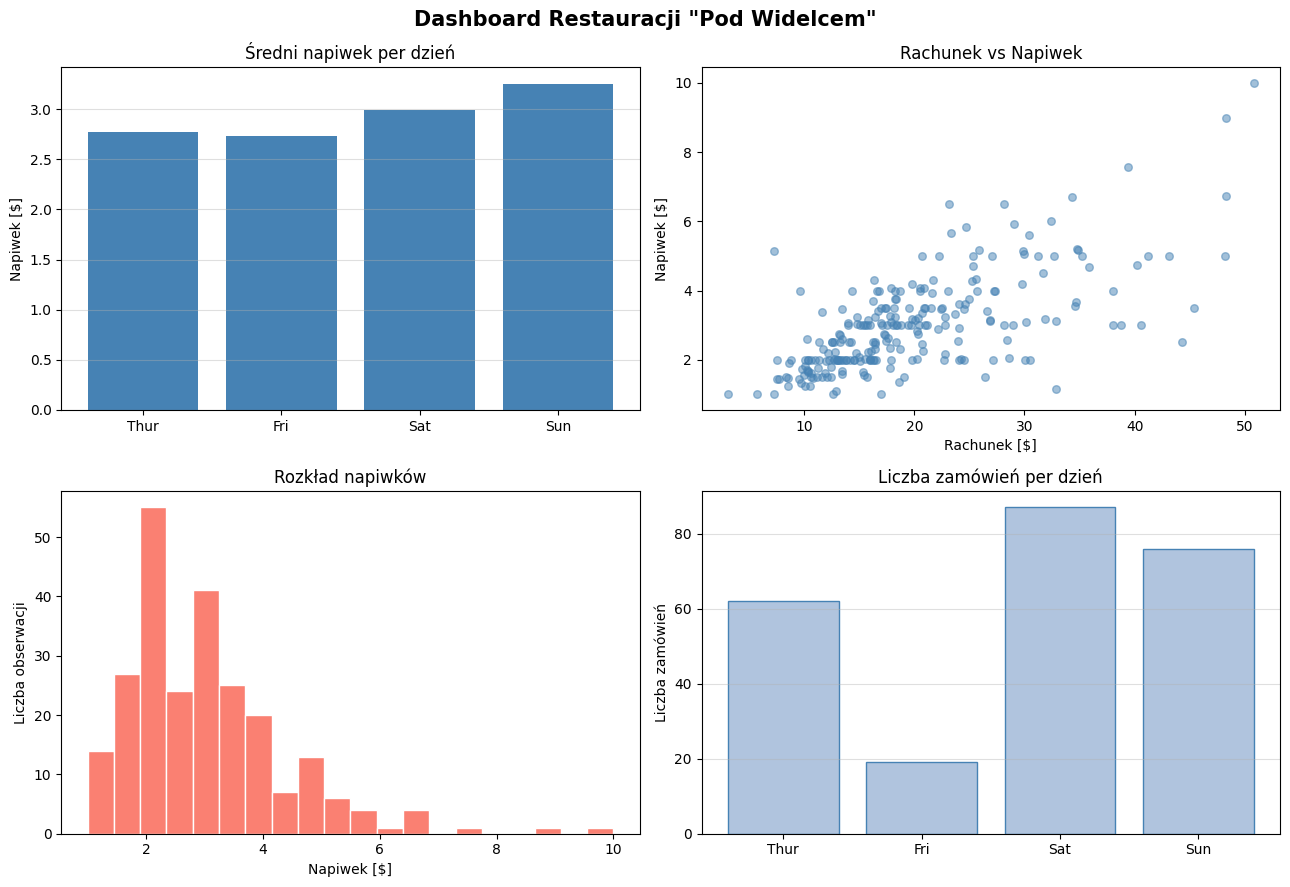

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# [0, 0] — Średni napiwek per dzień
sredni_napiwek_dzien = tips.groupby('day', observed=True)['tip'].mean()
axes[0, 0].bar(sredni_napiwek_dzien.index, sredni_napiwek_dzien.values, color='steelblue')
axes[0, 0].set_title('Średni napiwek per dzień')
axes[0, 0].set_ylabel('Napiwek [$]')
axes[0, 0].grid(axis='y', alpha=0.4)

# [0, 1] — Scatter: rachunek vs napiwek
axes[0, 1].scatter(tips['total_bill'], tips['tip'], alpha=0.5, color='steelblue', s=30) 
axes[0, 1].set_title('Rachunek vs Napiwek') 
axes[0, 1].set_xlabel('Rachunek [$]')
axes[0, 1].set_ylabel('Napiwek [$]')

# [1, 0] — Histogram napiwków
axes[1, 0].hist(tips['tip'], bins=20, color='salmon', edgecolor='white') 
axes[1, 0].set_title('Rozkład napiwków')
axes[1, 0].set_xlabel('Napiwek [$]')
axes[1, 0].set_ylabel('Liczba obserwacji')

# [1, 1] — Liczba zamówień per dzień
zamowienia_dzien = tips.groupby('day', observed=True)['total_bill'].count()
axes[1, 1].bar(zamowienia_dzien.index, zamowienia_dzien.values, color='lightsteelblue', edgecolor='steelblue')
axes[1, 1].set_title('Liczba zamówień per dzień')
axes[1, 1].set_ylabel('Liczba zamówień')
axes[1, 1].grid(axis='y', alpha=0.4)

plt.suptitle('Dashboard Restauracji "Pod Widelcem"', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('dashboard_tips.png', dpi=100)
plt.show()
plt.close()